In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel("part_4_marketing_budget_optimization.csv.xlsx")

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())

  CampaignID    Month   Region  TV_Spend  Radio_Spend  SocialMedia_Spend  \
0    MKT0001  2023-01     East     70.02        14.67              31.74   
1    MKT0002  2023-03    North     22.97        10.39              34.81   
2    MKT0003  2023-04  Central     40.01         5.02              43.38   
3    MKT0004  2023-05    North     40.84        37.61              15.26   
4    MKT0005  2023-05    South     39.63        23.68              55.48   

   SearchAds_Spend  Influencer_Spend  Sales_Revenue  
0            35.44              6.99         408.48  
1            39.11              0.37         365.55  
2            13.38             19.44         336.59  
3            30.91             13.76         409.73  
4            33.00             29.38         407.32  
(420, 9)
Index(['CampaignID', 'Month', 'Region', 'TV_Spend', 'Radio_Spend',
       'SocialMedia_Spend', 'SearchAds_Spend', 'Influencer_Spend',
       'Sales_Revenue'],
      dtype='object')
<class 'pandas.core.frame.Dat

# Data Understanding

This dataset contains marketing campaign spending data.

Each row represents one marketing campaign or time period with spend values across multiple channels and the resulting sales revenue.

## Columns
- CampaignID: unique campaign identifier
- Month: month of the campaign
- Region: region of the campaign
- TV_Spend: amount spent on TV ads
- Radio_Spend: amount spent on radio ads
- SocialMedia_Spend: amount spent on social media ads
- SearchAds_Spend: amount spent on search ads
- Influencer_Spend: amount spent on influencer marketing
- Sales_Revenue: total sales revenue generated

## Problem Type
This is a regression problem because Sales_Revenue is a continuous numeric variable.

## Why Regression is Useful
Regression helps estimate how marketing spend affects revenue and supports budget allocation decisions.

In [4]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

df["Month"] = df["Month"].astype(str)

df["SocialMedia_Spend"] = df["SocialMedia_Spend"].fillna(df["SocialMedia_Spend"].median())

print(df.isnull().sum())

Duplicate rows: 0
CampaignID           0
Month                0
Region               0
TV_Spend             0
Radio_Spend          0
SocialMedia_Spend    0
SearchAds_Spend      0
Influencer_Spend     0
Sales_Revenue        0
dtype: int64


# Data Cleaning

The dataset was checked for missing values, duplicates, and data type issues.

- Duplicate rows were checked and removed if present.
- Missing values in SocialMedia_Spend were replaced with the median value.
- Month was treated as a text field for reporting purposes.
- Numeric columns were verified for correct data types.

The cleaned dataset was then prepared for regression modeling.

In [5]:
print(df.describe())

         TV_Spend  Radio_Spend  SocialMedia_Spend  SearchAds_Spend  \
count  420.000000   420.000000         420.000000       420.000000   
mean    42.539643    20.895881          31.136857        37.182333   
std     26.705188    10.793881          16.720901        19.125876   
min      5.060000     2.100000           1.370000         3.090000   
25%     22.850000    11.747500          16.137500        20.220000   
50%     40.510000    20.905000          31.700000        35.465000   
75%     60.230000    30.255000          46.352500        54.345000   
max    343.400000    39.960000          59.800000        69.720000   

       Influencer_Spend  Sales_Revenue  
count        420.000000     420.000000  
mean          16.071881     418.964476  
std           13.751809      80.960572  
min            0.050000     211.970000  
25%            7.675000     364.635000  
50%           15.765000     420.495000  
75%           22.957500     470.435000  
max          179.820000     645.540000  


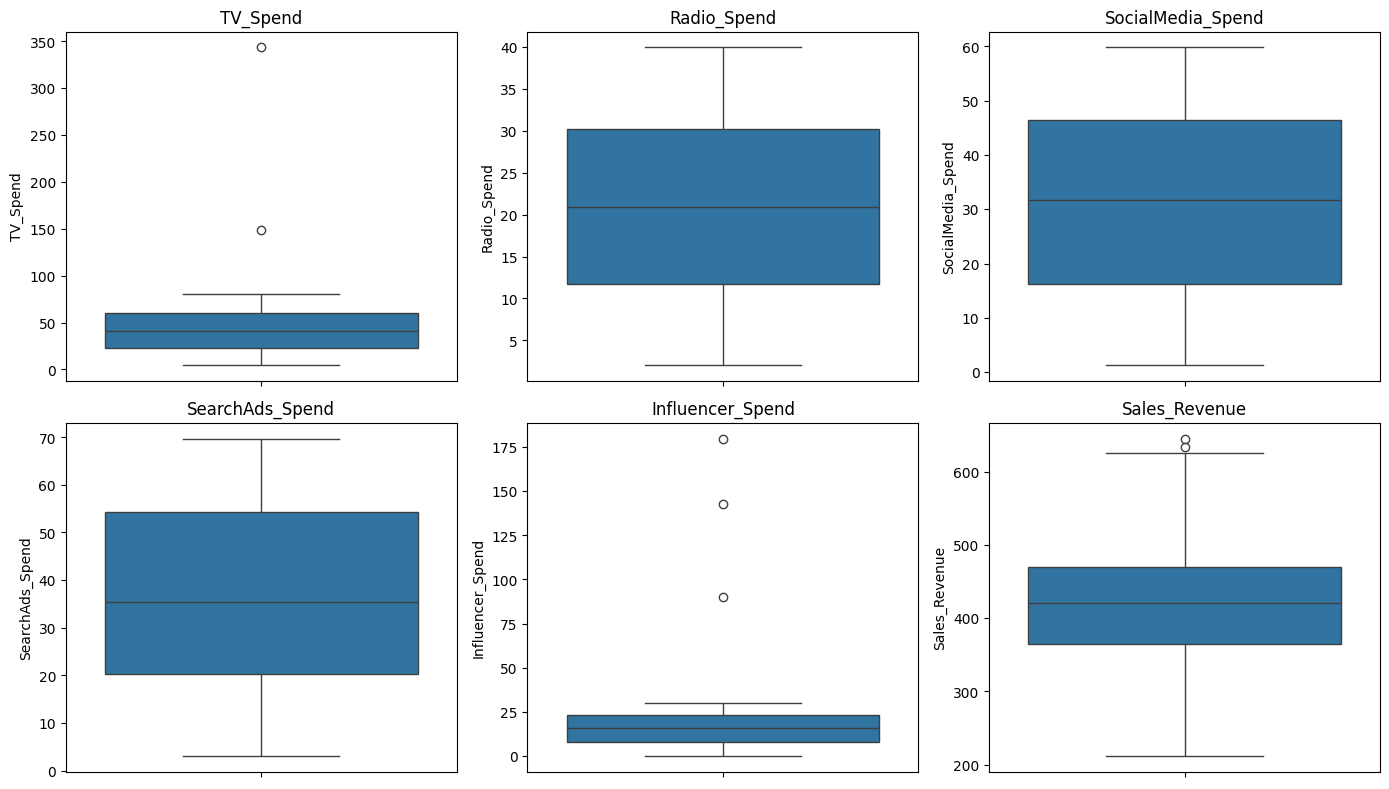

In [7]:
numeric_cols = [
    "TV_Spend",
    "Radio_Spend",
    "SocialMedia_Spend",
    "SearchAds_Spend",
    "Influencer_Spend",
    "Sales_Revenue"
]

plt.figure(figsize=(14,8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Data Quality Check

Summary statistics and boxplots were used to inspect the spread of the data and identify possible outliers.

Outliers are important because they can affect linear regression results and coefficient estimates.

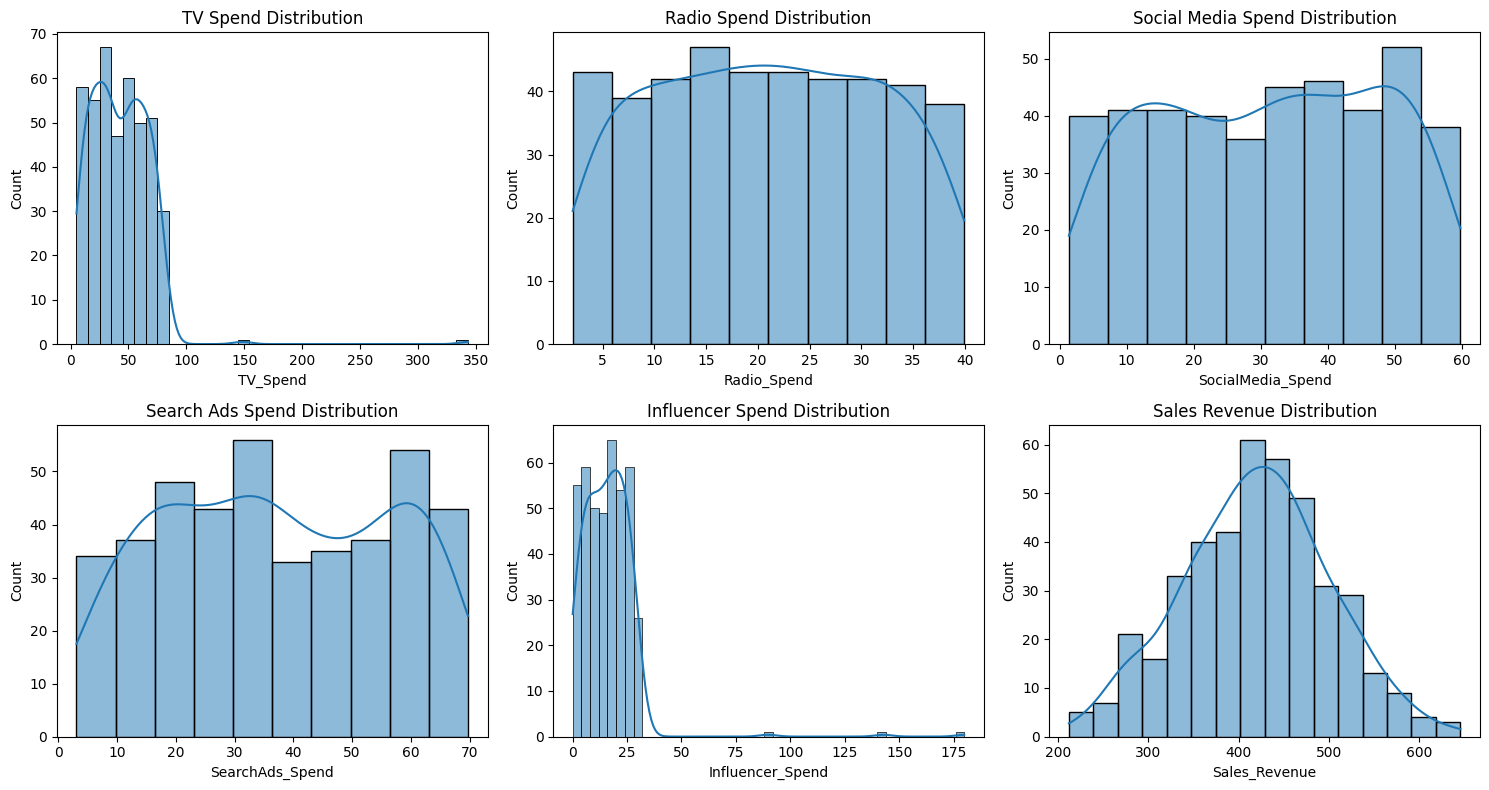

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))

sns.histplot(df["TV_Spend"], kde=True, ax=axes[0,0])
axes[0,0].set_title("TV Spend Distribution")

sns.histplot(df["Radio_Spend"], kde=True, ax=axes[0,1])
axes[0,1].set_title("Radio Spend Distribution")

sns.histplot(df["SocialMedia_Spend"], kde=True, ax=axes[0,2])
axes[0,2].set_title("Social Media Spend Distribution")

sns.histplot(df["SearchAds_Spend"], kde=True, ax=axes[1,0])
axes[1,0].set_title("Search Ads Spend Distribution")

sns.histplot(df["Influencer_Spend"], kde=True, ax=axes[1,1])
axes[1,1].set_title("Influencer Spend Distribution")

sns.histplot(df["Sales_Revenue"], kde=True, ax=axes[1,2])
axes[1,2].set_title("Sales Revenue Distribution")

plt.tight_layout()
plt.show()

The spend distributions show how the budget is spread across channels. Sales revenue distribution shows the variability in campaign performance.

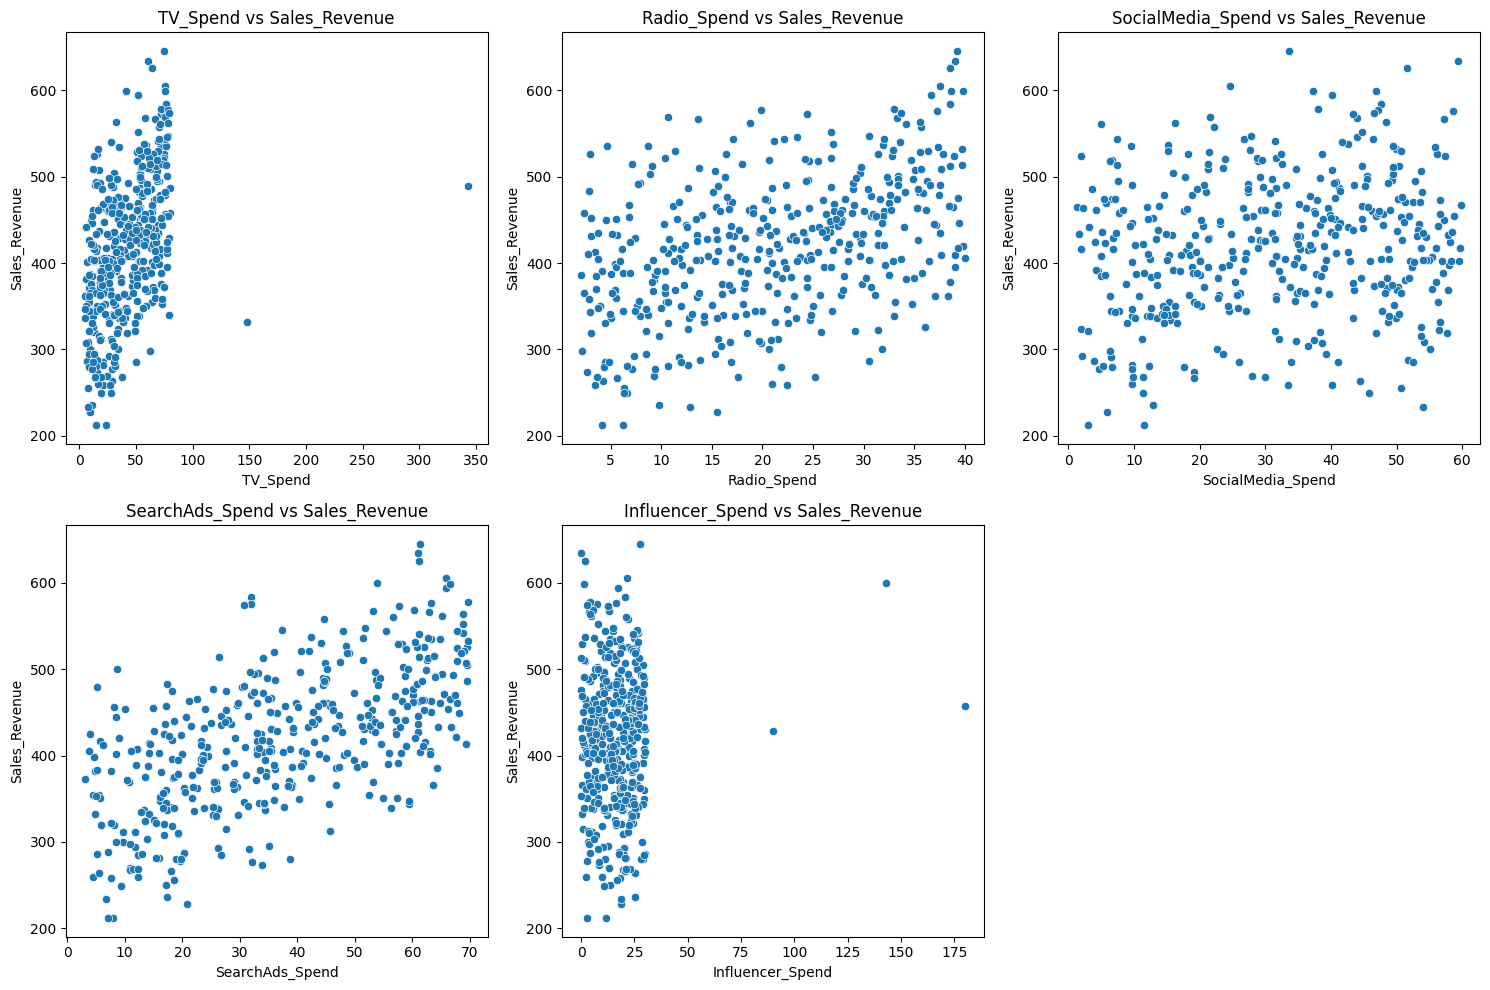

In [10]:
channels = [
    "TV_Spend",
    "Radio_Spend",
    "SocialMedia_Spend",
    "SearchAds_Spend",
    "Influencer_Spend"
]

plt.figure(figsize=(15,10))
for i, col in enumerate(channels, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=df[col], y=df["Sales_Revenue"])
    plt.title(f"{col} vs Sales_Revenue")

plt.tight_layout()
plt.show()

Scatter plots help show whether higher marketing spend tends to be associated with higher sales revenue.

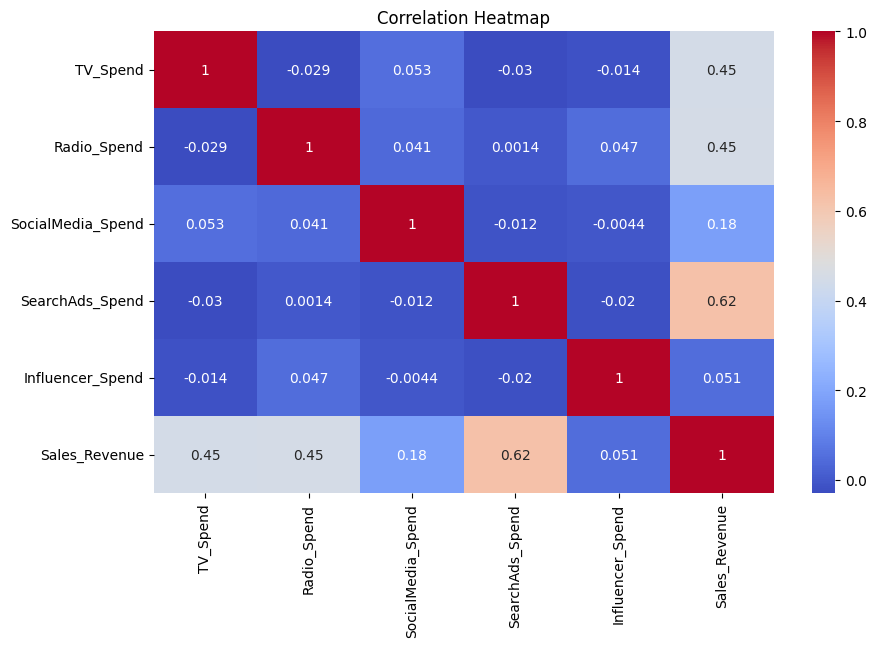

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [12]:
X = df[[
    "TV_Spend",
    "Radio_Spend",
    "SocialMedia_Spend",
    "SearchAds_Spend",
    "Influencer_Spend"
]]

y = df["Sales_Revenue"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [15]:
y_pred = model.predict(X_test)

In [16]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 19.86719485911624
MSE: 912.9760314230307
RMSE: 30.21549323481301
R2 Score: 0.8590996845175465


# Model Evaluation

- MAE shows the average absolute prediction error.
- MSE penalizes larger errors more heavily.
- RMSE gives error in the same unit as sales revenue.
- R² shows how much variance in sales is explained by the model.

A higher R² and lower error values indicate a better regression model.

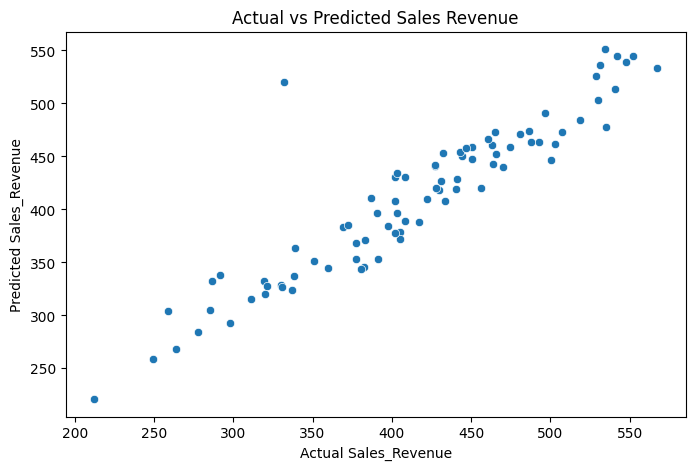

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Sales_Revenue")
plt.ylabel("Predicted Sales_Revenue")
plt.title("Actual vs Predicted Sales Revenue")
plt.show()

In [19]:
coef_df = pd.DataFrame({
    "Channel": X.columns,
    "Coefficient": model.coef_
})

coef_df = coef_df.sort_values("Coefficient", ascending=False)
print(coef_df)

             Channel  Coefficient
1        Radio_Spend     3.414455
3    SearchAds_Spend     2.674436
0           TV_Spend     1.445109
2  SocialMedia_Spend     0.696206
4   Influencer_Spend     0.202413


# Coefficient Interpretation

If the coefficient of Radio_Spend is high and positive, then radio advertising has a strong positive relationship with sales revenue.

If Influencer_Spend has a weak coefficient, it may mean influencer marketing is less effective in this dataset compared to other channels.

In [20]:
channel_summary = pd.DataFrame({
    "Channel": X.columns,
    "Total_Spend": X.sum(),
})

channel_summary["Spend_Share"] = channel_summary["Total_Spend"] / channel_summary["Total_Spend"].sum()

print(channel_summary)

                             Channel  Total_Spend  Spend_Share
TV_Spend                    TV_Spend     17866.65     0.287767
Radio_Spend              Radio_Spend      8776.27     0.141354
SocialMedia_Spend  SocialMedia_Spend     13077.48     0.210631
SearchAds_Spend      SearchAds_Spend     15616.58     0.251527
Influencer_Spend    Influencer_Spend      6750.19     0.108721


In [21]:
channel_corr = df[[
    "TV_Spend",
    "Radio_Spend",
    "SocialMedia_Spend",
    "SearchAds_Spend",
    "Influencer_Spend",
    "Sales_Revenue"
]].corr()["Sales_Revenue"].sort_values(ascending=False)

print(channel_corr)

Sales_Revenue        1.000000
SearchAds_Spend      0.622638
Radio_Spend          0.451547
TV_Spend             0.446413
SocialMedia_Spend    0.176114
Influencer_Spend     0.050514
Name: Sales_Revenue, dtype: float64


In [22]:
import os
os.makedirs("outputs", exist_ok=True)
os.makedirs("dataset", exist_ok=True)

In [23]:
df.to_csv("dataset/cleaned_marketing_data.csv", index=False)

In [24]:
coef_df.to_csv("outputs/channel_coefficients.csv", index=False)

In [25]:
channel_summary.to_csv("outputs/channel_summary.csv", index=False)

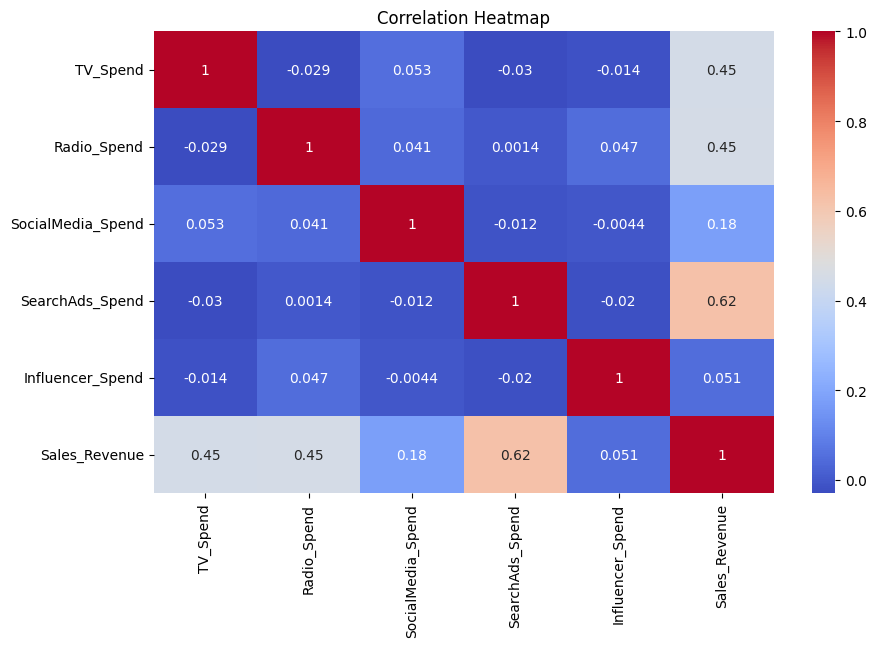

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("outputs/correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [27]:
import os

os.makedirs("outputs", exist_ok=True)

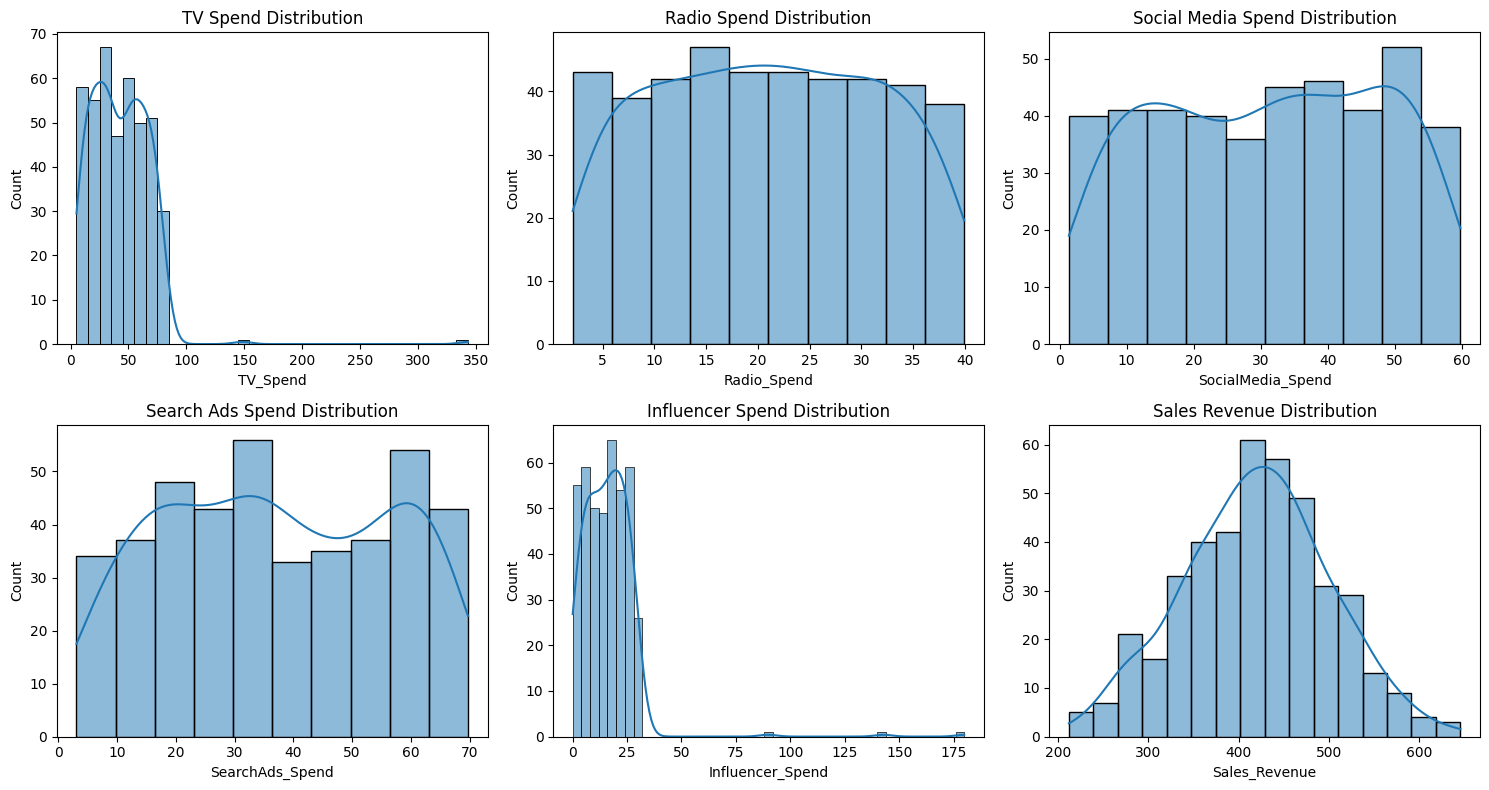

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))

sns.histplot(df["TV_Spend"], kde=True, ax=axes[0,0])
axes[0,0].set_title("TV Spend Distribution")

sns.histplot(df["Radio_Spend"], kde=True, ax=axes[0,1])
axes[0,1].set_title("Radio Spend Distribution")

sns.histplot(df["SocialMedia_Spend"], kde=True, ax=axes[0,2])
axes[0,2].set_title("Social Media Spend Distribution")

sns.histplot(df["SearchAds_Spend"], kde=True, ax=axes[1,0])
axes[1,0].set_title("Search Ads Spend Distribution")

sns.histplot(df["Influencer_Spend"], kde=True, ax=axes[1,1])
axes[1,1].set_title("Influencer Spend Distribution")

sns.histplot(df["Sales_Revenue"], kde=True, ax=axes[1,2])
axes[1,2].set_title("Sales Revenue Distribution")

plt.tight_layout()

plt.savefig(
    "outputs/distribution_plots.png",
    bbox_inches="tight"
)

plt.show()

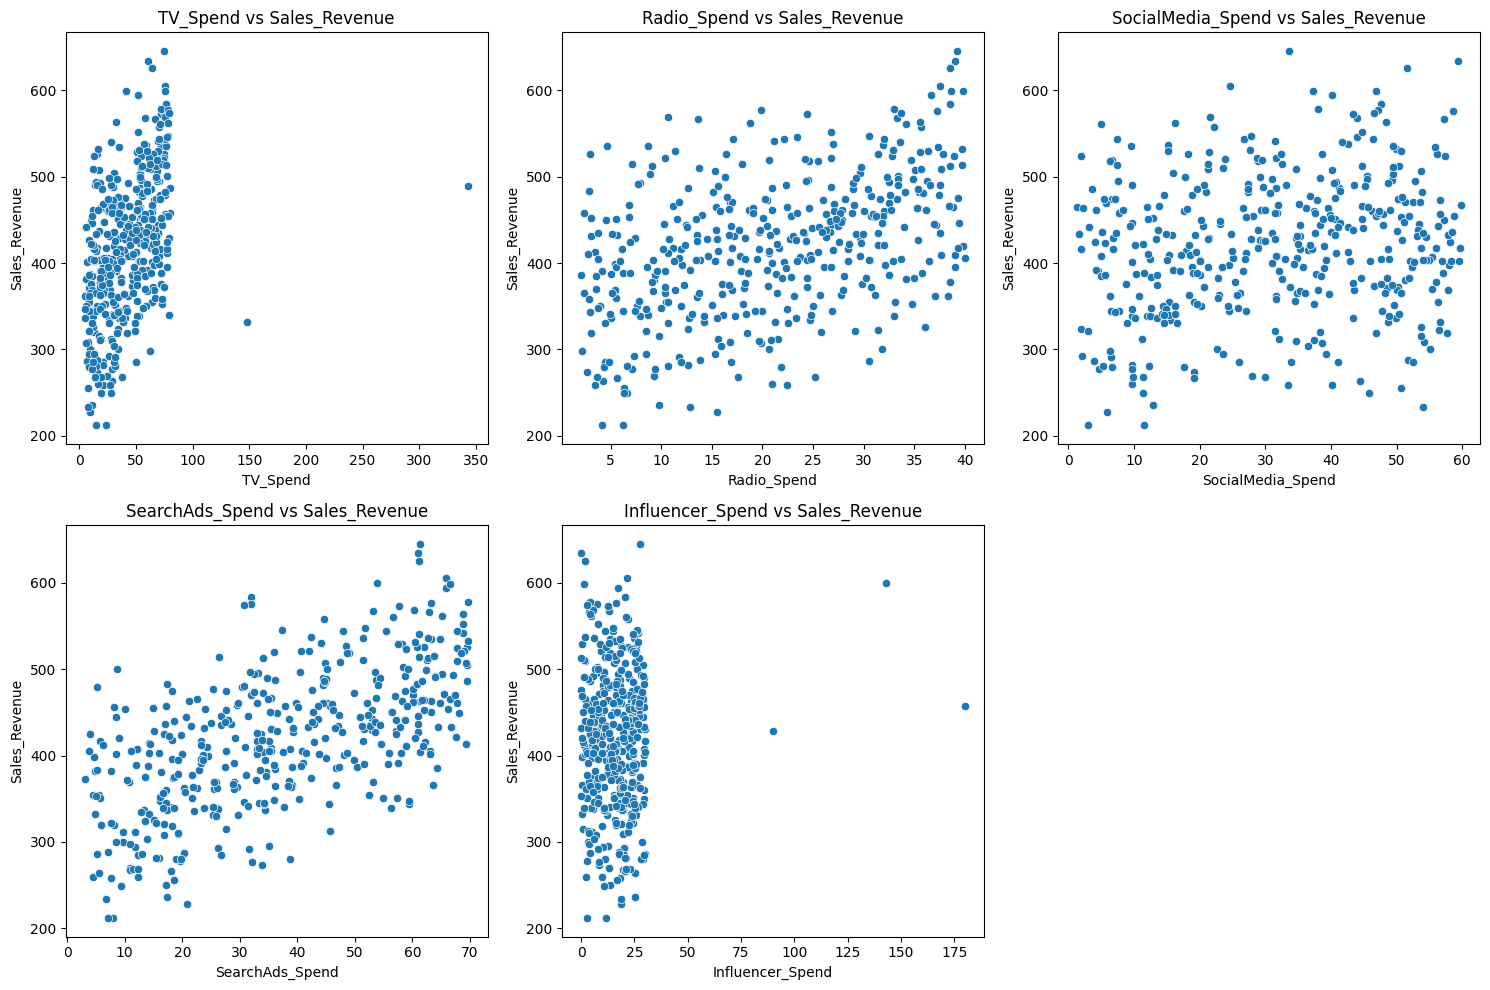

In [29]:
channels = [
    "TV_Spend",
    "Radio_Spend",
    "SocialMedia_Spend",
    "SearchAds_Spend",
    "Influencer_Spend"
]

plt.figure(figsize=(15,10))

for i, col in enumerate(channels, 1):
    plt.subplot(2, 3, i)

    sns.scatterplot(
        x=df[col],
        y=df["Sales_Revenue"]
    )

    plt.title(f"{col} vs Sales_Revenue")

plt.tight_layout()

plt.savefig(
    "outputs/channel_vs_sales.png",
    bbox_inches="tight"
)

plt.show()

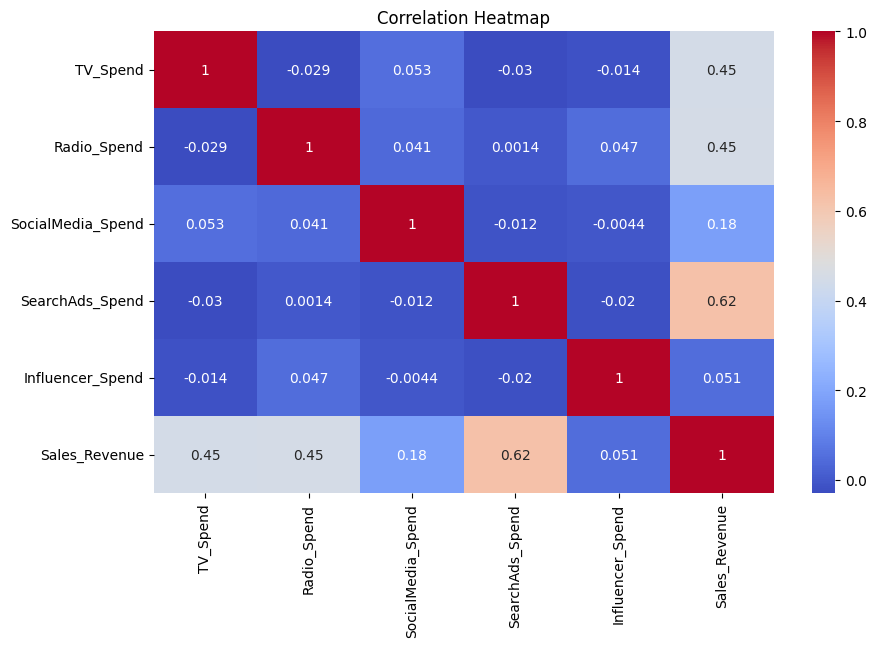

In [30]:
numeric_cols = [
    "TV_Spend",
    "Radio_Spend",
    "SocialMedia_Spend",
    "SearchAds_Spend",
    "Influencer_Spend",
    "Sales_Revenue"
]

plt.figure(figsize=(10,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "outputs/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

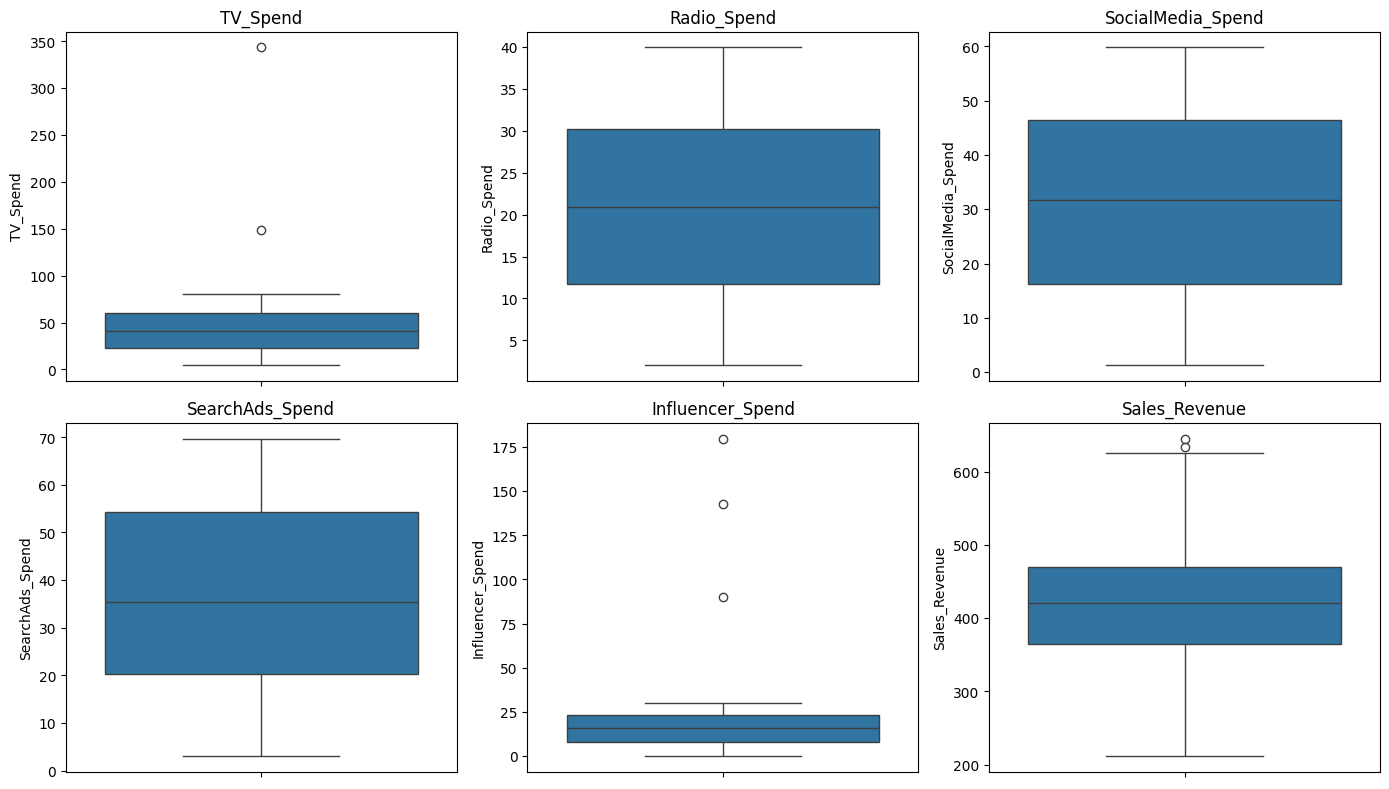

In [31]:
plt.figure(figsize=(14,8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.savefig(
    "outputs/outlier_boxplots.png",
    bbox_inches="tight"
)

plt.show()

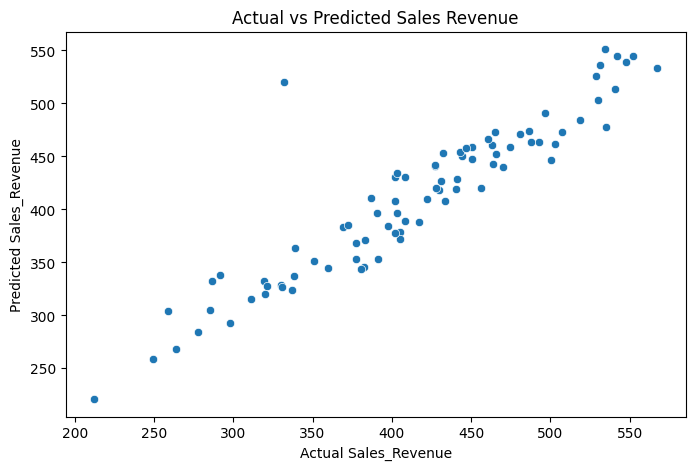

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.xlabel("Actual Sales_Revenue")
plt.ylabel("Predicted Sales_Revenue")

plt.title("Actual vs Predicted Sales Revenue")

plt.savefig(
    "outputs/actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

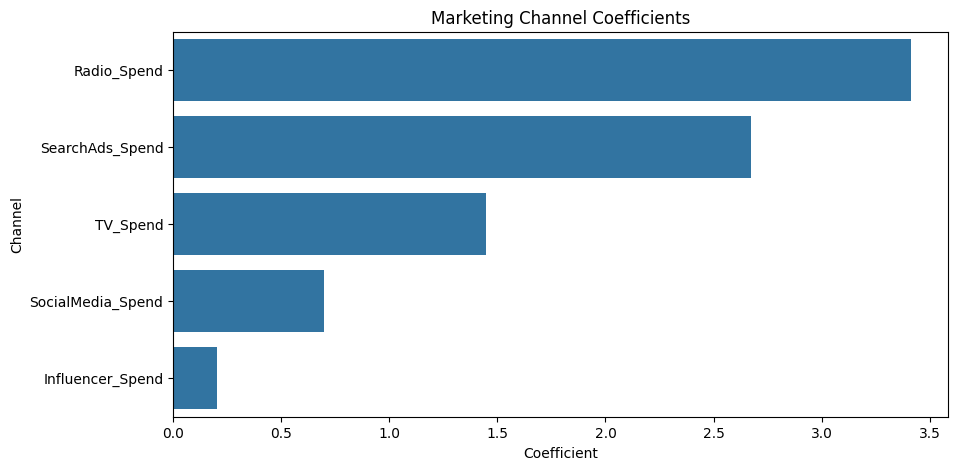

In [33]:
coef_df = pd.DataFrame({
    "Channel": X.columns,
    "Coefficient": model.coef_
})

coef_df = coef_df.sort_values(
    "Coefficient",
    ascending=False
)

plt.figure(figsize=(10,5))

sns.barplot(
    x="Coefficient",
    y="Channel",
    data=coef_df
)

plt.title("Marketing Channel Coefficients")

plt.savefig(
    "outputs/channel_coefficients.png",
    bbox_inches="tight"
)

plt.show()

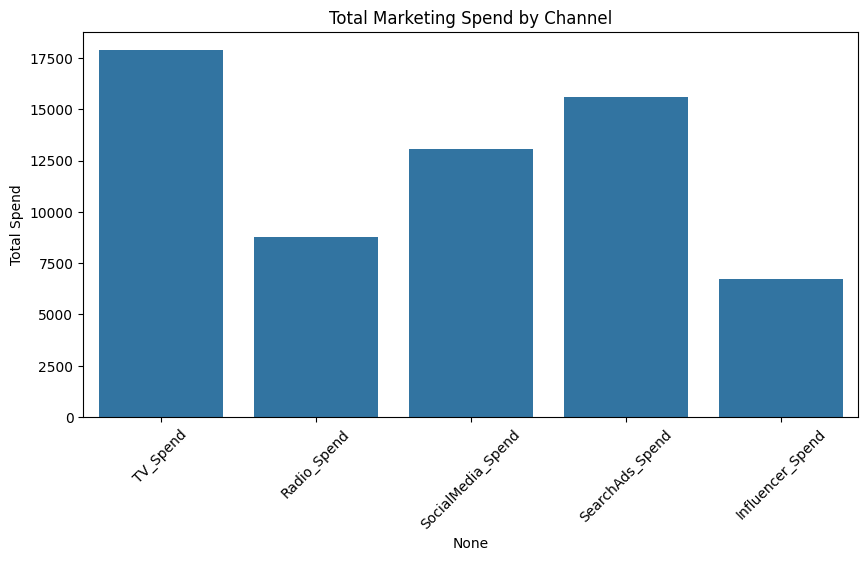

In [34]:
channel_spend = X.sum()

plt.figure(figsize=(10,5))

sns.barplot(
    x=channel_spend.index,
    y=channel_spend.values
)

plt.xticks(rotation=45)

plt.title("Total Marketing Spend by Channel")

plt.ylabel("Total Spend")

plt.savefig(
    "outputs/channel_spend.png",
    bbox_inches="tight"
)

plt.show()

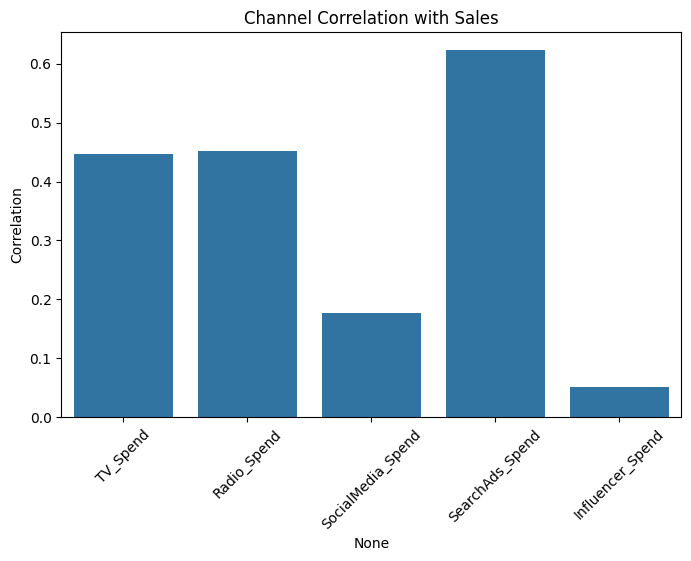

In [35]:
channel_corr = df[numeric_cols].corr()["Sales_Revenue"][:-1]

plt.figure(figsize=(8,5))

sns.barplot(
    x=channel_corr.index,
    y=channel_corr.values
)

plt.xticks(rotation=45)

plt.title("Channel Correlation with Sales")

plt.ylabel("Correlation")

plt.savefig(
    "outputs/channel_correlation.png",
    bbox_inches="tight"
)

plt.show()

In [37]:
channel_corr.to_csv(
    "outputs/channel_correlations.csv"
)